# Reranker

## 1. Multi-Query Hybrid Retrieval & Reranker Flow
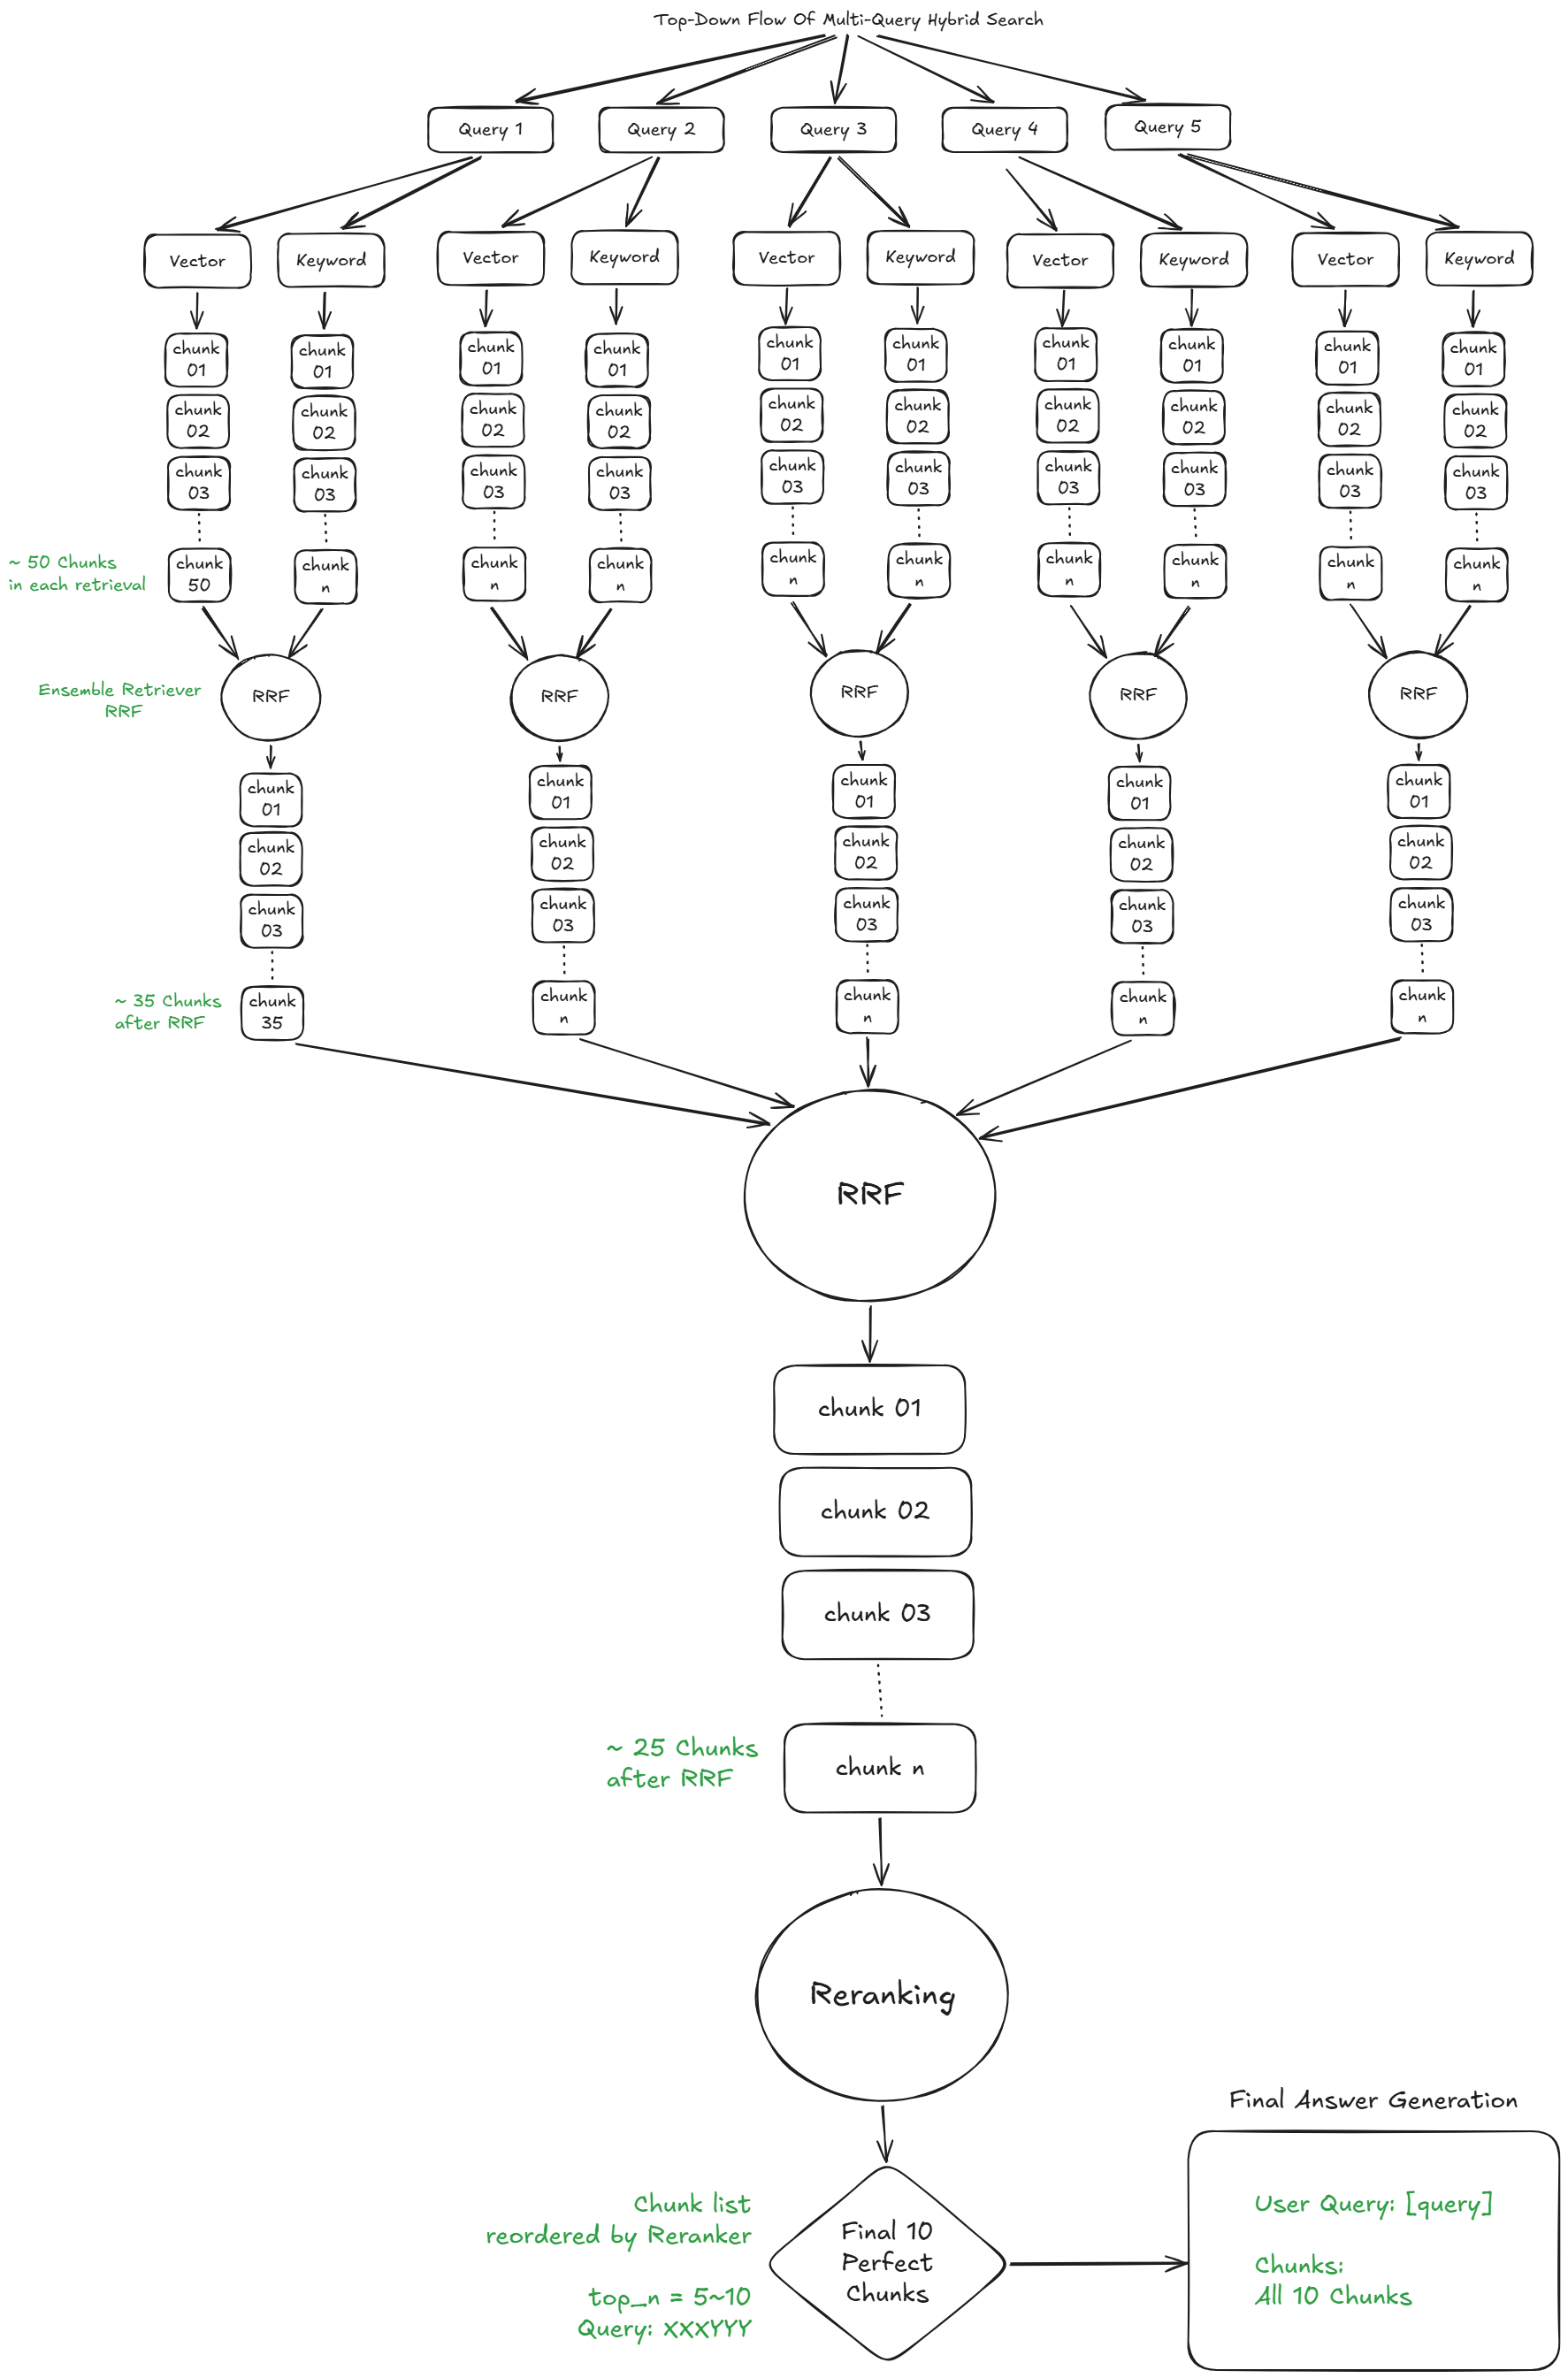

## 2. What is a Reranker?

A Reranker is a specialized AI Model that acts as a *Quality Inspector* that improves the initial search results by reordering them based on semantic relevance to your query.

Think of it as a *Second Opinion* system. Your initial retrieval (Result of Hybrid + RRF) might return 100 Chunks

> The Reranker takes these 100 Chunks and applies more sophisticated analysis to reorder them by putting the most relevant chunks at the top


## 3. Why do we even need a Reranker?

> *"I already have vector embeddings, hybrid search, multiquery and in the end, RRF (Reciprocal Rank Fusion) combining my results. I can extract the top k chunks from that set alone. Why do I need another layer of complexity with Rerankers? Isn't my hybrid + RRF results already good enough?"*

### 3.1 Embeddings Limitations:

Query: "*How to fix a leaky faucet?"*

- Chunk A: "*To fix a dripping tap, first turn off the water supply, then remove the handle and replace the worn washer."*

- Chunk B: "*Water damage from leaky faucet can cost homeowners thousands in repairs and lead to mold growth."*

**Embedding Similarity Scores:**

- Chunk A: 0.82 (High similarity)

- Chunk B: 0.79 (Also High similarity)

> Although embeddings and similarity scores help us retrieve chunks that have a good probability of being relevant, *good* is not good enough when you need a **HIGH-Accuracy RAG SYSTEM**

## 4. The Two-Stage Strategy

### 4.1 Stage 1: Embedding (Fast & Broad)

<div style="
  border: 2px solid white;
  padding: 10px;
  display: inline-block;
  font-family: monospace;
  background-color: black;
  color: white;
">
Query → Vector → Compare with 1M+ chunks → Top 100 chunks
</div>

**Purpose:** Inexpensive approximation
- Fast: Can search millions of chunks quickly
- Broad: Good at finding chunks in the right neighborhood
- Cheap: Low computational cost per comparison
- Reliable: Gives you chunks with good probability of relevance

> **BUT:** It's just an **APPROXIMATION**. You wouldn't bet your money on the exact ranking.

*Wouldn't be great if there was a **AI Model** that isn't as expensive as an LLM model but more accurate that (Simple Embeddings + Similarity Score) that could reorder the final 20 ~ 30 chunks accurately based on user query?*

### 4.2 Stage 2: Reranker (Precise & Focused)

<div style="
  border: 2px solid white;
  padding: 10px;
  display: inline-block;
  font-family: monospace;
  background-color: black;
  color: white;
">
Query → Each of 25 Chunks → Reranker/Cross-Encoder → Precise Relevance Scores
</div>

**Purpose:** Increase probability that top 10 are absolute best
- Precise: Actually reads query and chunks together
- Context-Aware: Understands query intent and relationships
- Expensive: Higher computational cost, but only for 10-100 Chunks usually

**<u>Why This Two-Stage Approach Works:</u>**

1. **Embeddings:** Cost a wide, inexpensive net to find chunk candidates
2. **Reranker:** Apply slightly more expensive but precise analysis to finalize ranking


## 5. How does Reranker (Cross-Encoder) achieve this?

**<u>Embeddings (Bi-Encoder Approach)</u>**
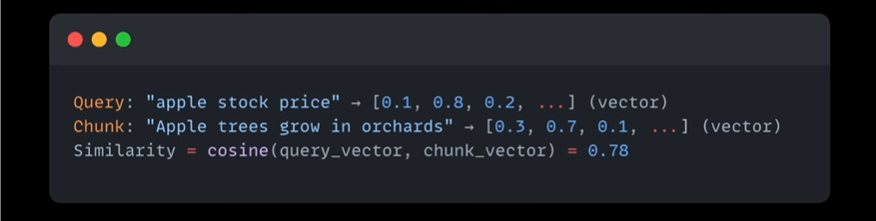
- The embeddings process happen **separately** for Query and Chunks
- Problem: The model never sees the query & chunks together. It just compare the math.

**<u>Reranker (Cross-Encoder / Joint-Processing Approach)</u>**
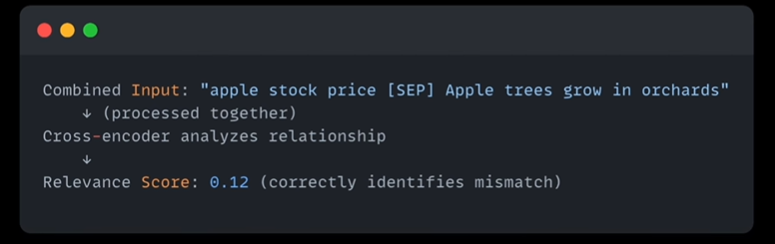
- Advantage: The reranker model reads **both** query and chunk simultaneously, understanding their relationship.
- Hence the process is 1 chunk follow by another chunk in sequence

## 6. Reranker Code with [Cohere Reranker](https://cohere.com/rerank)

### 6.1 Dependencies

In [1]:
!pip install langchain_cohere


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_cohere import CohereRerank
from dotenv import load_dotenv

load_dotenv()

True

### 6.2 Chunks & LangChain Documents Setup

In [4]:
chunks = [
    # Tesla - Financial & Production
    "Tesla reported record quarterly revenue of $25.2 billion in Q3 2024.",
    "Tesla's automotive gross margin improved to 19.3% this quarter.",
    "Tesla Cybertruck production ramp begins in 2024 with initial deliveries.",
    "Tesla announced plans to expand Gigafactory production capacity.",
    "Tesla stock price reached new highs following earnings announcement.",
    "Tesla's energy storage business grew 40% year-over-year.",
    "Tesla continues to lead in electric vehicle market share globally.",
    "Tesla Model Y became the best-selling vehicle worldwide.",
    "Tesla reported strong free cash flow generation of $7.5 billion.",
    "Tesla's Full Self-Driving revenue increased significantly.",
    
    # Microsoft - Development & Acquisitions
    "Microsoft acquired GitHub for $7.5 billion in 2018.",
    "Microsoft's cloud revenue Azure grew 29% year-over-year.",
    "Microsoft announced new AI features for Visual Studio Code.",
    "Microsoft Teams integration with GitHub enhances developer workflow.",
    "Microsoft's developer tools division sees strong adoption.",
    "Microsoft acquired Activision Blizzard for $68.7 billion.",
    "Microsoft's productivity suite gained 50 million new users.",
    "Microsoft announced new Surface devices for developers.",
    "Microsoft's AI Copilot features expand to more development tools.",
    "Microsoft's enterprise solutions drive revenue growth.",
    
    # NVIDIA - AI & Hardware
    "NVIDIA's data center revenue reached $47.5 billion annually.",
    "NVIDIA's H100 GPUs see unprecedented demand for AI training.",
    "NVIDIA announced next-generation Blackwell architecture.",
    "NVIDIA's gaming revenue declined due to crypto market changes.",
    "NVIDIA's automotive AI platform partnerships expanded.",
    "NVIDIA's AI chip shortage affects cloud providers.",
    "NVIDIA stock valuation exceeds $2 trillion market cap.",
    "NVIDIA's CUDA platform dominates AI development.",
    "NVIDIA announced new AI inference chips for edge computing.",
    "NVIDIA's partnership with major cloud providers strengthens.",
    
    # Google/Alphabet - AI & Cloud
    "Google's AI investments total over $100 billion in recent years.",
    "Google Cloud revenue grew 35% reaching $8.4 billion quarterly.",
    "Google announced Gemini AI model competing with GPT-4.",
    "Google's search advertising revenue remains strong at $59 billion.",
    "Google's Workspace products integrate advanced AI features.",
    "Google announced quantum computing breakthroughs.",
    "Google's autonomous vehicle division Waymo expands operations.",
    "Google's AI research published breakthrough papers.",
    "Google's cloud AI services see enterprise adoption.",
    "Google faces regulatory scrutiny over AI dominance.",
    
    # Noisy/Less Relevant Chunks
    "The Tesla coil was invented by Nikola Tesla in 1891.",
    "Microsoft Excel spreadsheet formulas can be complex for beginners.",
    "NVIDIA Shield TV streaming device gets software update.",
    "Google Maps navigation improved with real-time traffic data.",
    "Production delays affected multiple manufacturing sectors.",
    "Financial markets showed volatility during earnings season.",
    "Revenue recognition standards changed for software companies.",
    "Hardware components face supply chain constraints globally.",
    "Development tools market grows with remote work trends.",
    "AI research requires significant computational resources.",
    "Quarterly reports show mixed results across tech sector.",
    "Stock market analysts upgrade technology sector ratings.",
    "Cloud computing adoption accelerates in enterprise market.",
    "Data center construction increases globally.",
    "Semiconductor shortage impacts various industries.",
    "Electric vehicle charging infrastructure expands rapidly.",
    "Software development productivity tools gain popularity.",
    "Machine learning frameworks become more accessible.",
    "Enterprise software licensing models evolve.",
    "Technology conferences showcase latest innovations."
]

print(f"Created {len(chunks)} sample chunks for demonstration")

Created 60 sample chunks for demonstration


In [5]:
# Convert to Document objects
documents = [Document(page_content=chunk, metadata={"source": f"chunk_{i}"}) for i, chunk in enumerate(chunks)]

### 6.3 Vector Retriever (Semantic Search/Dense Retrieval)

In [7]:
print("Setting up Vector Retriever...")
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2"
)

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_metadata={"hnsw:space": "cosine"}
)
vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 15})

Setting up Vector Retriever...


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 7545.49it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 6.4 BM25 Retriever (Keyword Search/Sparse Retrieval)

In [8]:
# 2. BM25 Retriever
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 15

### 6.5 Hybrid Retriever

In [9]:
hybrid_retriever = EnsembleRetriever(
    retrievers=[vector_retriever, bm25_retriever],
    weights=[0.7, 0.3]
)

print("Setup complete!\n")

Setup complete!



### 6.6. Queries Testing in Hybrid Search¶

In [10]:
query = "Tesla financial performance and production updates"

print("STEP 1: Hybrid Search Results")
print("-"*50)

retrieved_docs = hybrid_retriever.invoke(query)  # Get top 25 for reranking

# Show top 10 from hybrid search
for i, doc in enumerate(retrieved_docs, 1):
    print(f"{i:2d}. {doc.page_content}")

print(f"\n(Retrieved {len(retrieved_docs)} total chunks for reranking)\n")

STEP 1: Hybrid Search Results
--------------------------------------------------
 1. Tesla reported record quarterly revenue of $25.2 billion in Q3 2024.
 2. Tesla announced plans to expand Gigafactory production capacity.
 3. Tesla reported strong free cash flow generation of $7.5 billion.
 4. Tesla Cybertruck production ramp begins in 2024 with initial deliveries.
 5. Tesla's automotive gross margin improved to 19.3% this quarter.
 6. Tesla's Full Self-Driving revenue increased significantly.
 7. Tesla's energy storage business grew 40% year-over-year.
 8. Tesla stock price reached new highs following earnings announcement.
 9. The Tesla coil was invented by Nikola Tesla in 1891.
10. Tesla Model Y became the best-selling vehicle worldwide.
11. Tesla continues to lead in electric vehicle market share globally.
12. Electric vehicle charging infrastructure expands rapidly.
13. Technology conferences showcase latest innovations.
14. Machine learning frameworks become more accessible.
15.

### 6.7 Apply Cohere Reranking

In [14]:
print("STEP 2: After Cohere Reranking (Top 10)")
print("-"*50)

# Initialize Cohere reranker
reranker = CohereRerank(model="rerank-english-v3.0", top_n=10)

# Rerank the retrieved documents
reranked_docs = reranker.compress_documents(retrieved_docs, query)

# Show reranked results
for i, doc in enumerate(reranked_docs, 1):
    print(f"{i:2d}. {doc.page_content}")

print("\n" + "="*80)
print("ANALYSIS:")
print("✅ Hybrid Search: Mixed relevant and irrelevant results")
print("✅ Reranking: Most relevant Tesla financial/production info at top")
print("✅ Notice how reranking moved the most contextually relevant chunks higher")

# Optional: Show the difference more clearly
print("\n" + "="*80)
print("KEY IMPROVEMENTS AFTER RERANKING:")
print("-"*40)


hybrid_top_5 = [doc.page_content for doc in retrieved_docs[:5]]
reranked_top_5= [doc.page_content for doc in reranked_docs[:5]]

print("BEFORE (Hybrid Top 5):")
for i, content in enumerate(hybrid_top_5, 1):
    print(f"  {i}. {content}")

print("\nAFTER (Reranked Top 5):")
for i, content in enumerate(reranked_top_5, 1):
    print(f"  {i}. {content}")

STEP 2: After Cohere Reranking (Top 10)
--------------------------------------------------
 1. Tesla reported strong free cash flow generation of $7.5 billion.
 2. Tesla reported record quarterly revenue of $25.2 billion in Q3 2024.
 3. Tesla's automotive gross margin improved to 19.3% this quarter.
 4. Tesla announced plans to expand Gigafactory production capacity.
 5. Tesla's energy storage business grew 40% year-over-year.
 6. Tesla continues to lead in electric vehicle market share globally.
 7. Tesla's Full Self-Driving revenue increased significantly.
 8. Tesla Cybertruck production ramp begins in 2024 with initial deliveries.
 9. Tesla stock price reached new highs following earnings announcement.
10. Financial markets showed volatility during earnings season.

ANALYSIS:
✅ Hybrid Search: Mixed relevant and irrelevant results
✅ Reranking: Most relevant Tesla financial/production info at top
✅ Notice how reranking moved the most contextually relevant chunks higher

KEY IMPROVEMEN

### 6.8 LLM Generation

In [15]:
query = "Tesla financial performance and production updates"
reranked_docs

[Document(metadata={'source': 'chunk_8', 'relevance_score': 0.5371628}, page_content='Tesla reported strong free cash flow generation of $7.5 billion.'),
 Document(metadata={'source': 'chunk_0', 'relevance_score': 0.48691094}, page_content='Tesla reported record quarterly revenue of $25.2 billion in Q3 2024.'),
 Document(metadata={'source': 'chunk_1', 'relevance_score': 0.14780103}, page_content="Tesla's automotive gross margin improved to 19.3% this quarter."),
 Document(metadata={'source': 'chunk_3', 'relevance_score': 0.023916386}, page_content='Tesla announced plans to expand Gigafactory production capacity.'),
 Document(metadata={'source': 'chunk_5', 'relevance_score': 0.020371294}, page_content="Tesla's energy storage business grew 40% year-over-year."),
 Document(metadata={'source': 'chunk_6', 'relevance_score': 0.0059340666}, page_content='Tesla continues to lead in electric vehicle market share globally.'),
 Document(metadata={'source': 'chunk_9', 'relevance_score': 0.00586533

In [16]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

print("\n" + "="*80)
print("FINAL: RAG with Reranked Context")
print("-"*40)

# Use top 5 reranked documents for final answer
top_reranked = reranked_docs[:5]

combined_input = f"""Based on the following documents, please answer this question: {query}

Documents:
{chr(10).join([f"- {doc.page_content}" for doc in top_reranked])}

Please provide a clear, helpful answer using only the information from these documents."""

model = ChatOpenAI(model="gpt-4o-mini")
messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content=combined_input),
]

result = model.invoke(messages)
print("Generated Response:")
print(result.content)


FINAL: RAG with Reranked Context
----------------------------------------
Generated Response:
In Q3 2024, Tesla demonstrated strong financial performance with a record quarterly revenue of $25.2 billion. The company also reported impressive free cash flow generation of $7.5 billion and an improvement in automotive gross margin, which rose to 19.3%. Additionally, Tesla's energy storage business experienced significant growth, increasing by 40% year-over-year. Furthermore, the company has plans to expand production capacity at its Gigafactory.


## 7. Production Tools

1. PG Vector - Open-source extension that enables vector similarity search within PostgreSQL
2. TS Vector -  PostgreSQL data type optimized for full-text search, representing a document as a sorted list of distinct, normalized words (lexemes)